In [1]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier

# Load Data
data = load_iris()
X = data.data
Y = data.target
feature_names = data.feature_names
class_names = data.target_names

x_train, x_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.25, stratify=Y, random_state=42
)

print('Train Samples : ', x_train.shape[0])
print('Test Samples : ', x_test.shape[0])

Train Samples :  112
Test Samples :  38


In [2]:
rf = RandomForestClassifier(
    random_state=42, 
    n_estimators=100,
    max_depth=None
)

rf.fit(x_train, y_train)

y_pred = rf.predict(x_test)

print('\n=============== Model Performance ===============')
print(f'Accuracy : {accuracy_score(y_test, y_pred):.3f}')
print('Confusion Matrix : ')
print(confusion_matrix(y_test, y_pred))


=============== Model Performance ===============
Accuracy : 0.921
Confusion Matrix : 
[[12  0  0]
 [ 0 12  1]
 [ 0  2 11]]


In [3]:
best_acc = 0
best_n = None
estimator = [50, 75, 100, 150, 200]

for n in estimator:
    model = RandomForestClassifier(
        random_state=42,
        n_estimators=n,
        max_depth=None,
        n_jobs=-1
    )

    model.fit(x_train, y_train)
    pred = model.predict(x_test)
    acc = round(accuracy_score(y_test, pred), 3)

    print(f'\nn_estimator={n} : Accuracy={acc}')
    if acc > best_acc:
        best_acc = acc
        best_n = n

    
    


n_estimator=50 : Accuracy=0.921

n_estimator=75 : Accuracy=0.947

n_estimator=100 : Accuracy=0.921

n_estimator=150 : Accuracy=0.895

n_estimator=200 : Accuracy=0.895


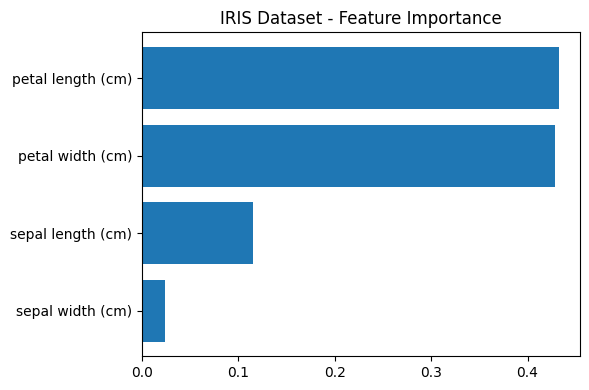

In [4]:
import matplotlib.pyplot as plt
importances = rf.feature_importances_
idx = np.argsort(importances)

plt.figure(figsize=(6,4))
plt.barh(np.array(feature_names)[idx], importances[idx])
plt.title('IRIS Dataset - Feature Importance')
plt.tight_layout()
plt.show()
